# SoSe26 General Tasks – Group 38

**Data path:** files under `Data/` (relative paths only).


In [16]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix
from sklearn.tree import export_text
from sklearn.linear_model import LinearRegression

DATA_DIR = Path("Data")

---

# 1. Logistics and Product Development in the Automobile Industry (8 points)

Task: create a distribution for the logistics delay of component **K7**.

Inputs:

- Production date (`Produktionsdatum`) from `Komponente_K7.csv`
- Receiving date (`Wareneingang`) from `Logistikverzug_K7.csv`
- Produced goods are issued **one day after** the production date
- Firstly build a new dataset **“Logistics delay”** with the required information from both files

### Approach

1. Load both files from `Data/Logistikverzug/` (relative paths).
2. Parse dates and merge on `IDNummer`.
3. Define the **issue date** as `Produktionsdatum + 1 day`.
4. Define **logistics delay (calendar days)** as `Wareneingang − issue date`.
5. Store the result in a dataset named `logistics_delay`.



In [17]:
# load data (separator: K7 uses ";", logistics file uses ",")
komponente_k7 = pd.read_csv(DATA_DIR / "Logistikverzug" / "Komponente_K7.csv", sep=";", index_col=0)
logistikverzug_k7 = pd.read_csv(DATA_DIR / "Logistikverzug" / "Logistikverzug_K7.csv", sep=",", index_col=0)

komponente_k7["Produktionsdatum"] = pd.to_datetime(komponente_k7["Produktionsdatum"])
logistikverzug_k7["Wareneingang"] = pd.to_datetime(logistikverzug_k7["Wareneingang"])

print(komponente_k7.shape, logistikverzug_k7.shape)
komponente_k7.head(3)

(306490, 5) (306490, 5)


,IDNummer,Produktionsdatum,Herstellernummer,Werksnummer,Fehlerhaft
1,K7-114-1142-1,2008-11-12,114,1142,0
2,K7-114-1142-2,2008-11-12,114,1142,0
3,K7-114-1142-3,2008-11-13,114,1142,0


In [18]:
# merge and calculate logistics delay
logistics_delay = komponente_k7.merge(
    logistikverzug_k7[["IDNummer", "Wareneingang"]],
    on="IDNummer",
    how="inner",
)

logistics_delay["Ausgabedatum"] = logistics_delay["Produktionsdatum"] + pd.Timedelta(days=1)
logistics_delay["Verzug_Tage"] = (
    logistics_delay["Wareneingang"] - logistics_delay["Ausgabedatum"]
).dt.days

print("Rows:", len(logistics_delay))
print(logistics_delay["Verzug_Tage"].describe())
logistics_delay.head()

Rows: 306490
count    306490.000000
mean          6.080437
std           1.012302
min           3.000000
25%           5.000000
50%           6.000000
75%           7.000000
max          14.000000
Name: Verzug_Tage, dtype: float64


,IDNummer,Produktionsdatum,Herstellernummer,Werksnummer,Fehlerhaft,Wareneingang,Ausgabedatum,Verzug_Tage
0,K7-114-1142-1,2008-11-12,114,1142,0,2008-11-19,2008-11-13,6
1,K7-114-1142-2,2008-11-12,114,1142,0,2008-11-19,2008-11-13,6
2,K7-114-1142-3,2008-11-13,114,1142,0,2008-11-20,2008-11-14,6
3,K7-114-1142-4,2008-11-13,114,1142,0,2008-11-20,2008-11-14,6
4,K7-114-1142-5,2008-11-13,114,1142,0,2008-11-19,2008-11-14,5


## 1a. How is the logistics delay distributed?

**Approach:**
1. Summarise the delay with central tendency and dispersion (mean, median, mode, variance, std, range, IQR) and a histogram.
2. Quick Poisson check: for Poisson, mean ≈ variance.
3. Compare candidate distributions with **χ² goodness-of-fit** and **AIC**.
4. Choose the better description.


Mean: 6.08
Median: 6.0
Mode: 6
Variance: 1.025
Std: 1.012
Min / Max: 3 / 14
Range: 11
IQR (Q3 - Q1): 2.0
Skewness: 0.567

Value counts:
Verzug_Tage
3         19
4       8499
5      81657
6     124094
7      67161
8      19973
9       4260
10       690
11       110
12        22
13         4
14         1
Name: count, dtype: int64


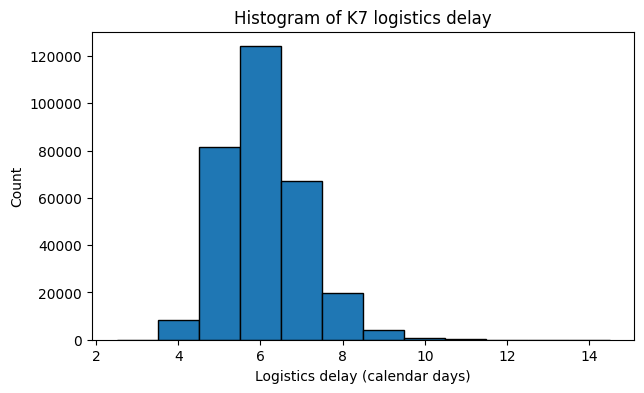

In [19]:
delay = logistics_delay["Verzug_Tage"]

print("Mean:", round(delay.mean(), 3))
print("Median:", round(delay.median(), 3))
print("Mode:", int(delay.mode().iloc[0]))
print("Variance:", round(delay.var(), 3))
print("Std:", round(delay.std(), 3))
print("Min / Max:", int(delay.min()), "/", int(delay.max()))
print("Range:", int(delay.max() - delay.min()))
q1, q3 = delay.quantile(0.25), delay.quantile(0.75)
print("IQR (Q3 - Q1):", round(q3 - q1, 3))
print("Skewness:", round(stats.skew(delay), 3))

print("\nValue counts:")
print(delay.value_counts().sort_index())

# Histogram
plt.figure(figsize=(7, 4))
plt.hist(delay, bins=range(int(delay.min()), int(delay.max()) + 2), edgecolor="black", align="left")
plt.xlabel("Logistics delay (calendar days)")
plt.ylabel("Count")
plt.title("Histogram of K7 logistics delay")
plt.show()

In [20]:
# Poisson check: for Poisson, mean = approx. variance
print("Poisson check: mean =", round(delay.mean(), 3), ", variance =", round(delay.var(), 3))
print("For a Poisson distribution, mean and variance should be about equal.")
print("Here variance << mean, so Poisson is already unlikely.\n")

#observed counts per delay value (whole days)
obs_counts = delay.value_counts().sort_index()
values = obs_counts.index.to_numpy()
observed = obs_counts.to_numpy(dtype=float)
n = len(delay)
mean_d = delay.mean()
std_d = delay.std()

#expected counts under Poisson(mean) and Normal(mean, std)
expected_poisson = stats.poisson.pmf(values, mean_d) * n
expected_normal = n * (
    stats.norm.cdf(values + 0.5, mean_d, std_d)
    - stats.norm.cdf(values - 0.5, mean_d, std_d)
)

#match totals (needed by chisquare)
expected_poisson *= observed.sum() / expected_poisson.sum()
expected_normal *= observed.sum() / expected_normal.sum()


def merge_small_bins(obs, exp, min_exp=5.0):
    """Merge neighbouring bins until each expected count is at least min_exp."""
    obs = list(obs.astype(float))
    exp = list(exp.astype(float))
    while len(exp) > 1 and exp[0] < min_exp:
        exp[1] += exp[0]
        obs[1] += obs[0]
        exp.pop(0)
        obs.pop(0)
    while len(exp) > 1 and exp[-1] < min_exp:
        exp[-2] += exp[-1]
        obs[-2] += obs[-1]
        exp.pop()
        obs.pop()
    return np.array(obs), np.array(exp)


obs_p, exp_p = merge_small_bins(observed, expected_poisson)
obs_n, exp_n = merge_small_bins(observed, expected_normal)

#x^2 goodness-of-fit (ddof = number of estimated parameters)
chi2_pois, p_pois = stats.chisquare(obs_p, exp_p, ddof=1)
chi2_norm, p_norm = stats.chisquare(obs_n, exp_n, ddof=2)

print("χ² goodness-of-fit (lower χ² = better relative fit):")
print(f"  Poisson: χ² = {chi2_pois:.1f}, p-value = {p_pois:.3e}")
print(f"  Normal:  χ² = {chi2_norm:.1f}, p-value = {p_norm:.3e}")
print("   The model with the smaller χ² fits the observed day counts better.\n")

# AIC comparison (lower AIC = better relative fit)
#formula AIC = 2k - 2 * log-likelihood
ll_pois = stats.poisson.logpmf(delay.astype(int), mean_d).sum()
ll_norm = stats.norm.logpdf(delay, mean_d, std_d).sum()
aic_pois = 2 * 1 - 2 * ll_pois   # 1 parameter: λ
aic_norm = 2 * 2 - 2 * ll_norm   # 2 parameters: mean, std

print("AIC comparison (lower AIC = better):")
print(f"  Poisson AIC = {aic_pois:.1f}")
print(f"  Normal  AIC = {aic_norm:.1f}")
print("   Normal wins as it has lower AIC.")

Poisson check: mean = 6.08 , variance = 1.025
For a Poisson distribution, mean and variance should be about equal.
Here variance << mean, so Poisson is already unlikely.

χ² goodness-of-fit (lower χ² = better relative fit):
  Poisson: χ² = 230025.2, p-value = 0.000e+00
  Normal:  χ² = 16443.5, p-value = 0.000e+00
   The model with the smaller χ² fits the observed day counts better.

AIC comparison (lower AIC = better):
  Poisson AIC = 1171781.0
  Normal  AIC = 877278.6
   Normal wins as it has lower AIC.


### Answer 1a

- Central tendency: mean ≈ **6.08** days, median = **6**, mode = **6**. Most delays sit at 5–7 days.
- Dispersion: std ≈ **1.01**, variance ≈ **1.02**, range = 3–14 days, IQR ≈ **2** days → the mass of the data is quite narrow.
- Skewness is mildly positive -> a slight right tail (rare longer delays).
- **Not Poisson:** variance ≪ mean. χ² and AIC also rank Poisson much worse than Normal.
- **Approximately Normal:** smaller χ² and lower AIC than Poisson. With very large *n*, *p*-values can still be tiny, so we mainly use the **relative** comparison.
- **Conclusion:** logistics delay is best described as **approximately normally distributed** (mean ≈ 6 days, sd ≈ 1 day).


## 1b. Mean logistics delay in working days

**Task:** determine the mean logistics delay in **working days** (weekends excluded). Interpret the number and discuss possible alternatives.

**Approach:**
1. Count only Monday–Friday between issue date (`Ausgabedatum`) and receipt (`Wareneingang`) with `numpy.busday_count`.
2. Compute mean, median, std and a **95% confidence interval** for the mean.
3. Compare with the calendar-day mean from 1a.


Mean delay (working days): 4.344
Median delay (working days): 4.0
Std (working days): 0.888
95% CI for the mean: [ 4.34 , 4.347 ]
Mean delay (calendar days): 6.08

Working-day delay counts:
Verzug_Arbeitstage
1          5
2       3641
3      49017
4     114425
5     120690
6      15661
7       2666
8        337
9         40
10         8
Name: count, dtype: int64


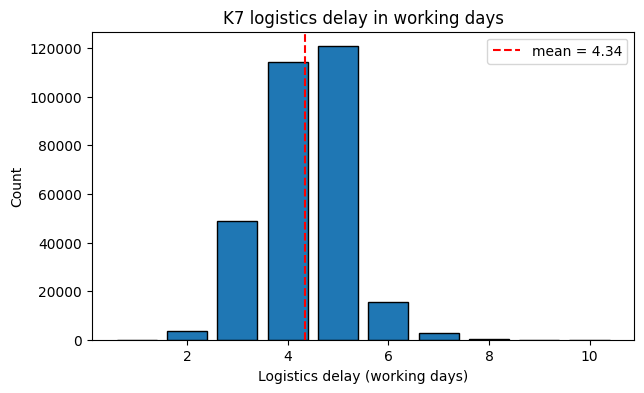

In [21]:
# Working days = Mon–Fri only between issue date and receipt
logistics_delay["Verzug_Arbeitstage"] = np.busday_count(
    logistics_delay["Ausgabedatum"].values.astype("datetime64[D]"),
    logistics_delay["Wareneingang"].values.astype("datetime64[D]"),
)

wd = logistics_delay["Verzug_Arbeitstage"]
mean_wd = wd.mean()
median_wd = wd.median()
std_wd = wd.std()
n_wd = len(wd)
mean_cal = logistics_delay["Verzug_Tage"].mean()

# 95% confidence interval for the mean: mean ± 1.96 * SE
se_wd = std_wd / np.sqrt(n_wd)
ci_low = mean_wd - 1.96 * se_wd
ci_high = mean_wd + 1.96 * se_wd

print("Mean delay (working days):", round(mean_wd, 3))
print("Median delay (working days):", round(median_wd, 3))
print("Std (working days):", round(std_wd, 3))
print("95% CI for the mean: [", round(ci_low, 3), ",", round(ci_high, 3), "]")
print("Mean delay (calendar days):", round(mean_cal, 3))
print("\nWorking-day delay counts:")
print(wd.value_counts().sort_index())

# Bar chart
wd_counts = wd.value_counts().sort_index()
plt.figure(figsize=(7, 4))
plt.bar(wd_counts.index, wd_counts.values, edgecolor="black")
plt.axvline(mean_wd, color="red", linestyle="--", label=f"mean = {mean_wd:.2f}")
plt.xlabel("Logistics delay (working days)")
plt.ylabel("Count")
plt.title("K7 logistics delay in working days")
plt.legend()
plt.show()

### Answer 1b

- Mean logistics delay ≈ **4.34 working days** (median ≈ **4**, std ≈ **0.89**).
- The **95% CI** for the mean is extremely narrow (around 4.34) because *n* is very large → the mean is estimated very precisely.
- **Interpretation:** after K7 leaves the supplier (one day after production), it typically arrives at the OEM in about **4–5 working days**.
- The calendar-day mean (~6.1) is higher because **weekends** count in elapsed time but are not working days.
- **Alternatives:**
  - use the **median** instead of the mean (more robust to rare long delays);
  - also exclude **public holidays**;
  - compute means **separately per plant/manufacturer** if logistics differs by site.


## 1c. Histogram and density (plotly) 

Plot histogram + density with **plotly**. Explain the bin size.


In [22]:
#bin size is 1 day, because delay is already measured in whole days
fig = px.histogram(
    logistics_delay, x="Verzug_Tage",
    nbins=int(delay.max() - delay.min() + 1),
    histnorm="probability density",
    title="K7 logistics delay: histogram and density",
    labels={"Verzug_Tage": "Logistics delay (calendar days)"},)
fig.update_traces(name="Histogram (density)", opacity=0.75)

#simple normal density curve using mean and std from the data
x_grid = np.linspace(delay.min() - 1, delay.max() + 1, 200)
y_grid = stats.norm.pdf(x_grid, delay.mean(), delay.std())
fig.add_scatter(x=x_grid, y=y_grid, mode="lines", name="Normal density")

fig.show()

### Answer (1c)

- **Bin size = 1 day**, because the delay is counted in whole days. Each bar then stands for one possible delay value.
- The red line is a **Normal density** with the sample mean and standard deviation (from 1a).


## 1d. Decision tree for defective K7

**Task:** describe how to build a decision tree that classifies whether K7 is defective (`Fehlerhaft`). Use a visualisation.

We have followed the lecture workflow for decision trees:
1. Define the prediction problem (supervised classification).
2. Choose attributes (features).
3. Train–test split → `.fit` on train, `.predict` on test.
4. Grow a small tree (prefer attributes that separate the classes well).
5. Visualise and interpret the tree.



Target class counts (labelled data = supervised learning):
Fehlerhaft
0    306484
1         6
Name: count, dtype: int64
  0 = OK, 1 = defective

Train size: 214543 | Test size: 91947

Accuracy on test set: 0.5413
Confusion matrix (rows = true, columns = predicted):
[[49768 42177]
 [    1     1]]

Attribute importance (higher = used more for splits):
  Herstellernummer: 0.000
  Werksnummer: 0.382
  Verzug_Tage: 0.618

Tree rules:
|--- Werksnummer <= 1137.0
|   |--- Verzug_Tage <= 7.5
|   |   |--- class: 1
|   |--- Verzug_Tage >  7.5
|   |   |--- class: 0
|--- Werksnummer >  1137.0
|   |--- Verzug_Tage <= 6.5
|   |   |--- class: 0
|   |--- Verzug_Tage >  6.5
|   |   |--- class: 0



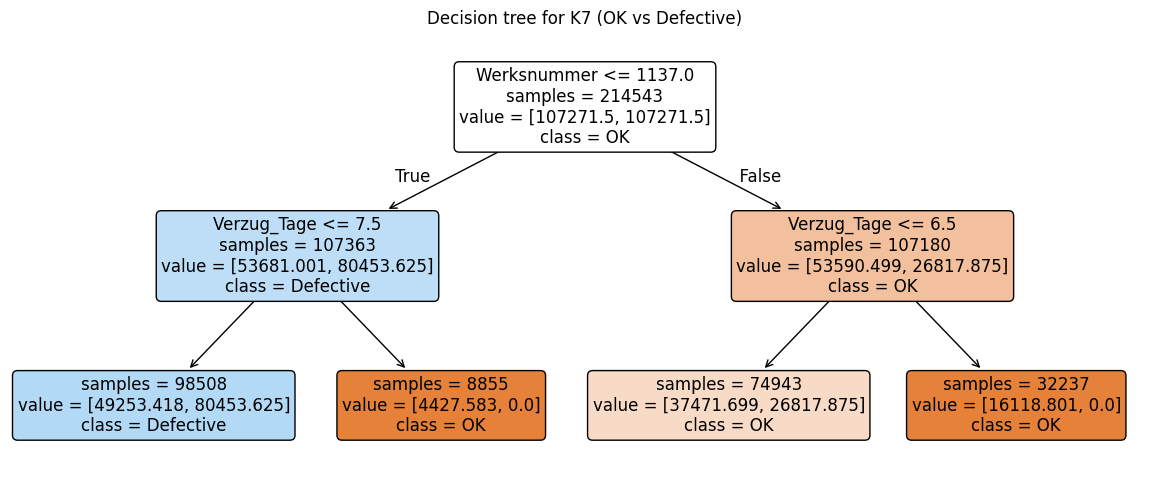

In [23]:
# Y = Fehlerhaft (0 = OK, 1 = defective)
# X = attributes that might help explain Y
features = ["Herstellernummer", "Werksnummer", "Verzug_Tage"]
X = logistics_delay[features]
y = logistics_delay["Fehlerhaft"]

print("Target class counts (labelled data = supervised learning):")
print(y.value_counts())
print("  0 = OK, 1 = defective\n")

#train–test split (.fit on train, .predict on test) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print("Train size:", len(X_train), "| Test size:", len(X_test))

# criterion="entropy" -> splits use information gain 
# max_depth=2 -> small tree (classify with few attributes)
tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=2,
    random_state=42,
    class_weight="balanced",  
)
tree.fit(X_train, y_train) #train
y_pred = tree.predict(X_test) #test

print("\nAccuracy on test set:", round(tree.score(X_test, y_test), 4))
print("Confusion matrix (rows = true, columns = predicted):")
print(confusion_matrix(y_test, y_pred))

# attribute importance = which features the tree used most 
print("\nAttribute importance (higher = used more for splits):")
for name, imp in zip(features, tree.feature_importances_):
    print(f"  {name}: {imp:.3f}")

# vizualisation 
print("\nTree rules:")
print(export_text(tree, feature_names=features, decimals=1))

plt.figure(figsize=(12, 5))
plot_tree(
    tree,
    feature_names=features,
    class_names=["OK", "Defective"],
    filled=True,
    rounded=True,
    impurity=False,
    fontsize=12,
)
plt.title("Decision tree for K7 (OK vs Defective)")
plt.tight_layout()
plt.show()

### Answer 1d 

**1. Problem**  
Supervised classification: predict `Fehlerhaft` (OK / defective) from known labels (same idea as the lecture example “Stolen? Yes/No”).

**2. Attributes**  
`Herstellernummer`, `Werksnummer`, `Verzug_Tage`.  
The tree picks the best splits first (information gain / entropy).

**3. Train–test split**  
- Train -> `tree.fit(...)`  
- Test -> `tree.predict(...)`  
This checks whether the rules still work on unseen data (avoid overfitting).

**4. Model**  
Small tree (`max_depth=2`, `criterion="entropy"`).  
`class_weight="balanced"` because almost all parts are OK (only 6 defectives).

**5. How to read the plot**  
Start at the top (root). Each box is a question about an attribute.  
Left = condition true, right = false → final leaf = **OK** or **Defective**.

---

# 2. Data Storage in Separate Files 

Explain why it makes sense to store the available data in **separate files** instead of one large table. Name **at least four benefits**. The available tables represent a typical database structure — **what is this structure called?**


**Structure:** Relational database (relational data model). The data are stored in separate tables (rows and columns) that are linked by unique identifiers (keys). Each table has a fixed set of attributes with consistent data types.

**Benefits of separate files / tables:**
- **Less redundancy:** shared attributes (e.g. municipality names) are stored once instead of being repeated in every row of one large table.
- **Better performance:** smaller tables are faster to load, filter, and join than one very wide and long table that holds everything.
- **Easier maintenance and fewer update anomalies:** a change (e.g. correcting a place name) only needs to be made in one place, which reduces inconsistencies and manual errors.
- **Flexibility and access control:** different teams can work with only the tables they need (parts, vehicles, registrations), which also supports clearer data security and responsibilities.


---

# 3. Parts T16 in Registered Vehicles 

Determine how many parts **T16** ended up in vehicles registered in **Adelshofen**.


**Approach:**

1. Search for `T16` in `Komponente` -> found in `Bestandteile_Komponente_K2LE2` and `Bestandteile_Komponente_K2ST2`.
2. Each seat component (`ID_K2LE2` / `ID_K2ST2`) contains one `ID_T16`.
3. In `Fahrzeug`, OEM2 vehicles reference seats via `ID_Sitze` in `Bestandteile_Fahrzeuge_OEM2_Typ21` and `Bestandteile_Fahrzeuge_OEM2_Typ22`.
4. Join seats -> T16 parts -> vehicles -> `Zulassungen_aller_Fahrzeuge` (via `ID_Fahrzeug` = `IDNummer`).
5. Filter for `Gemeinden == "ADELSHOFEN"` and count the T16 parts.


In [24]:
# Count T16 parts in vehicles registered in Adelshofen
k2le2 = pd.read_csv(DATA_DIR / "Komponente" / "Bestandteile_Komponente_K2LE2.csv", sep=";", index_col=0)
k2st2 = pd.read_csv(DATA_DIR / "Komponente" / "Bestandteile_Komponente_K2ST2.csv", sep=";", index_col=0)
Bestandteile_Fahrzeuge_OEM2_Typ21 = pd.read_csv(DATA_DIR / "Fahrzeug" / "Bestandteile_Fahrzeuge_OEM2_Typ21.csv", sep=";", index_col=0)
Bestandteile_Fahrzeuge_OEM2_Typ22 = pd.read_csv(DATA_DIR / "Fahrzeug" / "Bestandteile_Fahrzeuge_OEM2_Typ22.csv", sep=";", index_col=0)
Zulassungen_aller_Fahrzeuge = pd.read_csv(DATA_DIR / "Zulassungen" / "Zulassungen_alle_Fahrzeuge.csv", sep=";", index_col=0)

# map each seat (ID_Sitze) to its T16 part
seat_t16 = pd.concat([k2le2.rename(columns={"ID_K2LE2": "ID_Sitze"})[["ID_Sitze", "ID_T16"]],
    k2st2.rename(columns={"ID_K2ST2": "ID_Sitze"})[["ID_Sitze", "ID_T16"]],], ignore_index=True)

# combine OEM2 vehicle tables and link to T16 parts and registrations
vehicles = pd.concat([Bestandteile_Fahrzeuge_OEM2_Typ21, Bestandteile_Fahrzeuge_OEM2_Typ22], ignore_index=True)

tot_table = (vehicles.merge(seat_t16, on="ID_Sitze", how="inner").merge(Zulassungen_aller_Fahrzeuge, left_on="ID_Fahrzeug", right_on="IDNummer", how="left"))

# filter for Adelshofen and count T16 parts
num_t16_adelshofen = (tot_table["Gemeinden"] == "ADELSHOFEN").sum()
print(f"Number of T16 parts in vehicles registered in Adelshofen: {num_t16_adelshofen}")

# checking for duplicates
tot_table.duplicated(subset="ID_Fahrzeug").sum()


Number of T16 parts in vehicles registered in Adelshofen: 48


0

**Answer:**
There are **48 T16 parts** in vehicles registered in Adelshofen.


---

# 4. Attributes of the Registration Table 

Identify the **data types** of the attributes in `Zulassungen_aller_Fahrzeuge`. Present the answers in a **Markdown table** and briefly describe the characteristics of the data types.


In [25]:
#load dataset
Zulassungen_aller_Fahrzeuge = pd.read_csv(DATA_DIR / "Zulassungen" / "Zulassungen_alle_Fahrzeuge.csv", sep=";", index_col=0)

# Inspect dtypes of Zulassungen_aller_Fahrzeuge
print(Zulassungen_aller_Fahrzeuge.head())
print(Zulassungen_aller_Fahrzeuge.dtypes)


         IDNummer Gemeinden   Zulassung
408097  11-1-11-1   DRESDEN  2009-01-01
408098  11-1-11-2   DRESDEN  2009-01-01
1       12-1-12-1   LEIPZIG  2009-01-01
2       12-1-12-2   LEIPZIG  2009-01-01
3       12-1-12-3  DORTMUND  2009-01-01
IDNummer     object
Gemeinden    object
Zulassung    object
dtype: object


| Attribute | Stored data type (pandas) | Characteristics |
|-----------|---------------------------|-----------------|
| IDNummer | object (string) | Qualitative / nominal identifier. Labels a vehicle; values look numeric but must not be used for arithmetic. |
| Gemeinden | object (string) | Qualitative / nominal. Categorical place names (municipalities) with no natural order. |
| Zulassung | object (string) | Stored as text on import. After `pd.to_datetime()`, it is a date/time on an interval scale (differences between dates are meaningful). |

**Note:** in the CSV, all three attributes arrive as strings (`object`). For analysis, `Zulassung` should be converted to datetime; `IDNummer` and `Gemeinden` should stay as categorical/text identifiers.


---

# 5. Linear Model for Mileage

From `Fahrzeuge_OEM1_Typ11_Fehleranalyse`, create a **linear model** relating mileage to suitable variables. Derive **recommendations for OEM1** based on this model.


**Approach:**

1. loading the data and look at the header
2. plot multiple scatterplots (mileage vs date, mileage vs engine, mileage vs fuel)
3. mileage vs date is to spread out, mileage vs engine is only categorised into three types --> deciding on mileage vs fuel
4. plot linear model

gradient: 4480.5
y-intercept: 23456.2
R²: 0.475
engine
large     72082.532987
medium    60136.138333
small     41364.678474
Name: Fehlerhaft_Fahrleistung, dtype: float64
engine
small      3.951364
medium     8.169922
large     11.950987
Name: fuel, dtype: float64


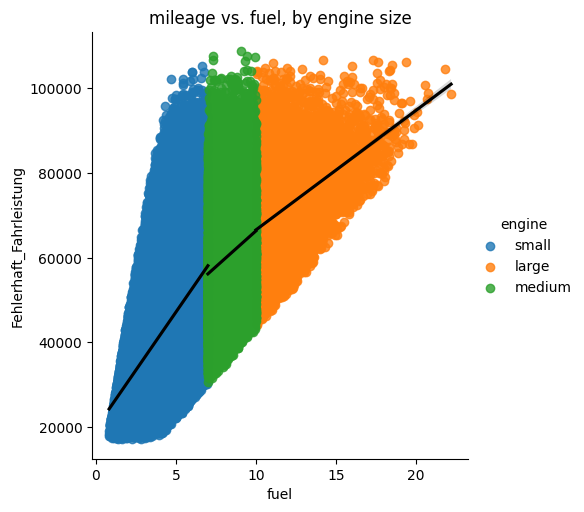

In [26]:
#load dataset
OEM1  = pd.read_csv(DATA_DIR / "Fahrzeug" / "Fahrzeuge_OEM1_Typ11_Fehleranalyse.csv", sep=",", index_col=0)

# creating a linear model

X = OEM1[["fuel"]]                    
y = OEM1["Fehlerhaft_Fahrleistung"]   

model = LinearRegression()
model.fit(X, y)

print("gradient:", round(model.coef_[0], 1))
print("y-intercept:", round(model.intercept_, 1))
print("R²:", round(model.score(X, y), 3))

print(OEM1.groupby("engine")["Fehlerhaft_Fahrleistung"].mean())
print(OEM1.groupby("engine")["fuel"].mean().sort_values())

# plotting the graph
sns.lmplot(data=OEM1, x="fuel", y="Fehlerhaft_Fahrleistung", hue="engine",
         line_kws=dict(color="black"))
plt.title("mileage vs. fuel, by engine size")

plt.show()

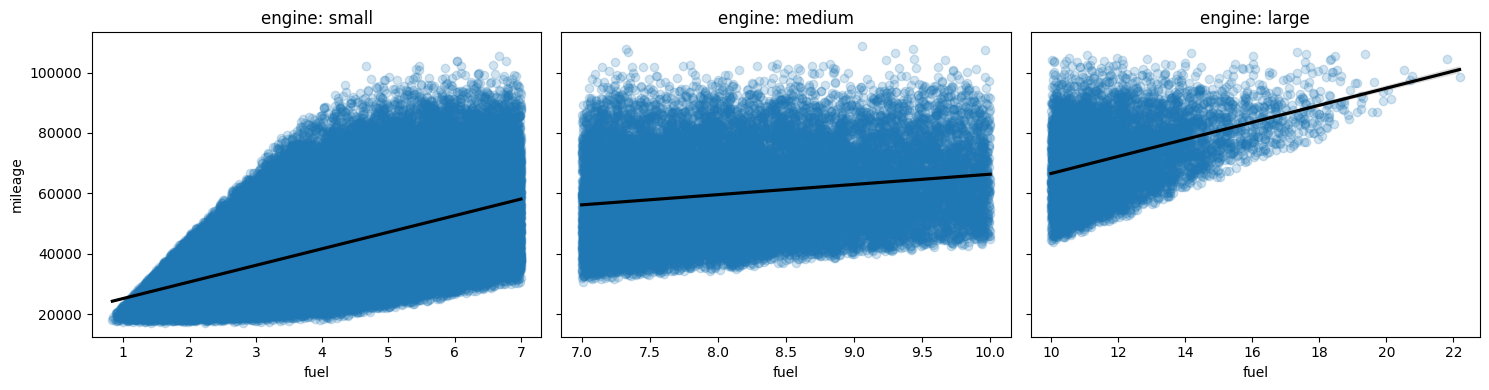

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

engine_typen = ["small", "medium", "large"]

for ax, typ in zip(axes, engine_typen):
    daten = OEM1[OEM1["engine"] == typ]
    sns.regplot(data=daten, x="fuel", y="Fehlerhaft_Fahrleistung",
                line_kws=dict(color="black"), scatter_kws=dict(alpha=0.2), ax=ax)
    ax.set_title(f"engine: {typ}")
    ax.set_xlabel("fuel")
    ax.set_ylabel("mileage" if typ == "small" else "")

plt.tight_layout()
plt.show()

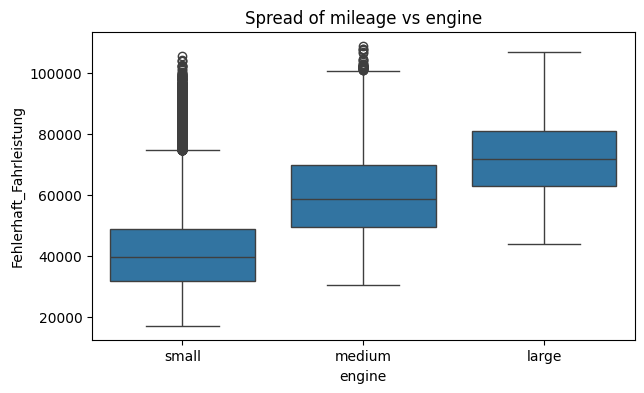

In [28]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=OEM1, x="engine", y="Fehlerhaft_Fahrleistung", order=["small","medium","large"])
plt.title("Spread of mileage vs engine")
plt.show()

**Answer:**
Interpretation:
- positive linear relation (R^2=0.475, explains roughly half): more fuel --> more miles before errors occur   
- the data is relatively wide spread, not monotonically increasing with fuel, peaks mid-fuel range (≈7–9, mean mileage ~60,000 km) and narrows again at higher fuel levels (far fewer vehicles in that range)
- fuel averages suggest bigger engines get further, but at the same fuel unit the larger the engine the earlier the failure 
- gradient: for each unit of fuel there are 4480km more mileage
- intercept: does not have any physical relevance, since a car with 0 fuel would have to drive 23456.2km 

Advice:
- regular maintenance due to linear correlation
- review large engines more frequently
- since days is not correlated to mileage, maintenance should be based on fuel consumption
- larger engines may have more errors at the same fuel units compared to small and medium but also less outliers
- use graphs as direction not as absolute (R^2 just 0.475)

---

# 6. Hit and Run Accident Investigation 

On **11.08.2010** there was a hit-and-run accident. The license plate is unknown. Find where the vehicle with body part number **`K5-112-1122-79`** was registered.


**Approach:**

1. Search for body part `K5-112-1122-79` in `Fahrzeug` -> found in `Bestandteile_Fahrzeuge_OEM1_Typ12` (`ID_Karosserie`).
2. Read the corresponding vehicle ID (`ID_Fahrzeug`).
3. Join with `Zulassungen_aller_Fahrzeuge` via `IDNummer` = `ID_Fahrzeug`.
4. Read the registration municipality (`Gemeinden`).

**Note:** The accident date (11.08.2010) is background information. The registration location comes from the registration table.


In [31]:
# trace body part K5-112-1122-79 -> vehicle -> registration location
BODY_PART = "K5-112-1122-79"

Bestandteile_Fahrzeuge_OEM1_Typ12 = pd.read_csv(DATA_DIR / "Fahrzeug" / "Bestandteile_Fahrzeuge_OEM1_Typ12.csv", sep=";", index_col=0)
Zulassungen_aller_Fahrzeuge = pd.read_csv(DATA_DIR / "Zulassungen" / "Zulassungen_alle_Fahrzeuge.csv", sep=";", index_col=0)

vehicle_parts = Bestandteile_Fahrzeuge_OEM1_Typ12.loc[Bestandteile_Fahrzeuge_OEM1_Typ12["ID_Karosserie"] == BODY_PART]

registration = Zulassungen_aller_Fahrzeuge.merge(vehicle_parts[["ID_Fahrzeug"]],left_on="IDNummer", right_on="ID_Fahrzeug",how="inner")

print(f"Body part: {BODY_PART}")
print(f"Vehicle ID: {registration['IDNummer'].iloc[0]}")
print(f"Registration municipality: {registration['Gemeinden'].iloc[0]}")
print(f"Registration date: {registration['Zulassung'].iloc[0]}")

Body part: K5-112-1122-79
Vehicle ID: 12-1-12-82
Registration municipality: ASCHERSLEBEN
Registration date: 2009-01-02


**Answer:**
The vehicle with body part `K5-112-1122-79` (vehicle ID `12-1-12-82`) was registered in **ASCHERSLEBEN**.
